In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

In [9]:
nci60 = pd.read_csv("NCI60.csv")
nci60_X = nci60.iloc[:,1:-1]

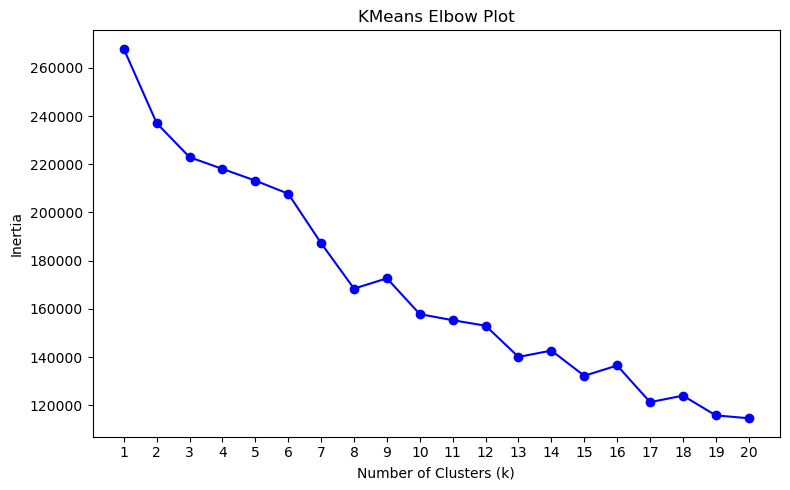

In [10]:
#Problem 1

inertias = []
K_range = range(1, 21)

for k in K_range:
    km = KMeans(n_clusters=k)
    km.fit(nci60_X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('KMeans Elbow Plot')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

We look for the "elbow" where inertia stops dropping steeply and begins to level off. That inflection point suggests a good tradeoff between compactness and model complexity.

Typically no for the NCI60 data. The inertia curve tends to decrease gradually without a sharp, obvious elbow, making it hard to pinpoint a single correct K. The indicator is a heuristic, not a definitive rule, especially in high-dimensional data (6830 features) where distances compress and distinctions between K values become subtle.

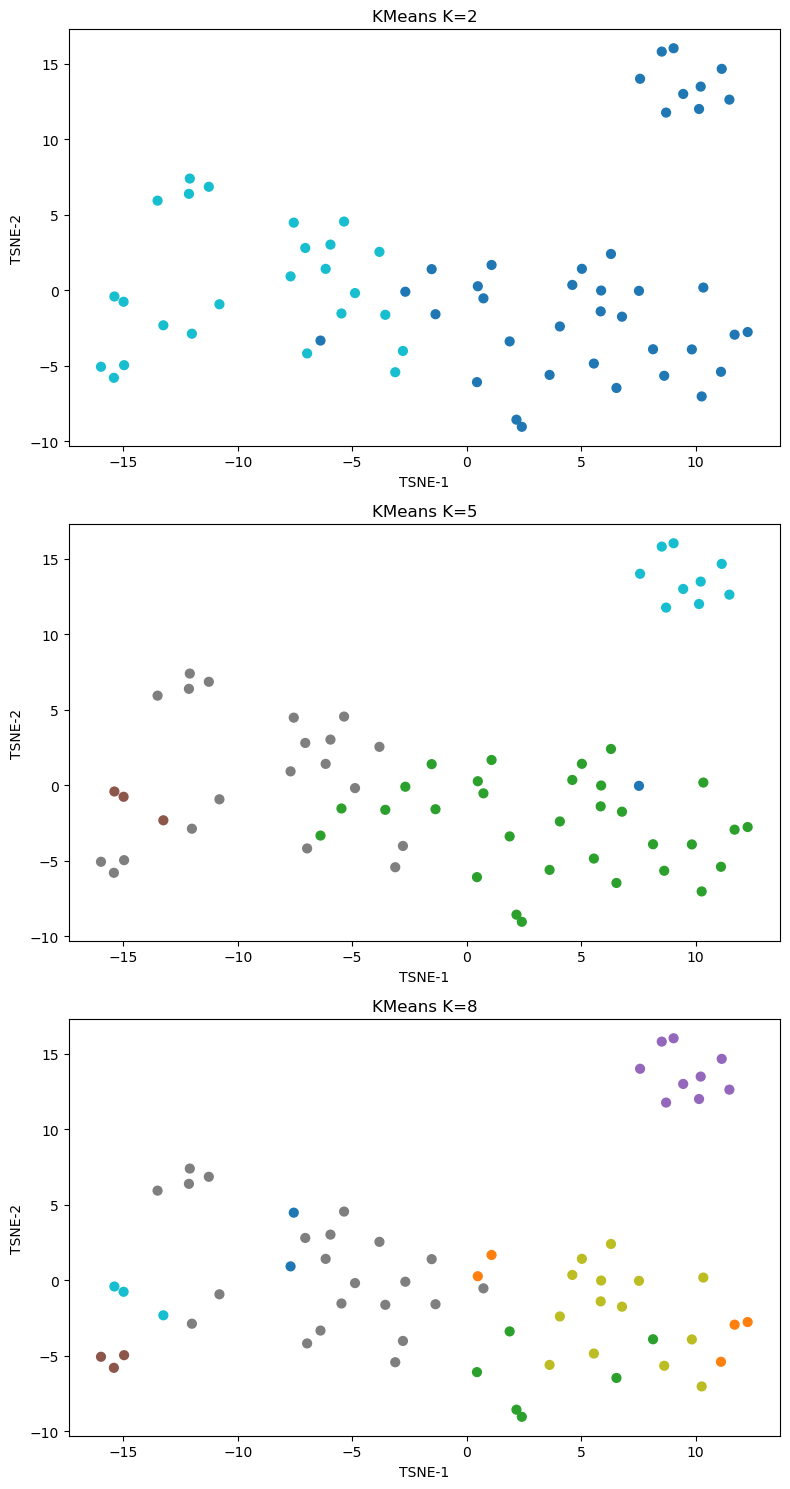

In [11]:
#Problem 2

tsne = TSNE(n_components=2, perplexity=10)
X_embedded = tsne.fit_transform(nci60_X)

fig, axes = plt.subplots(3, 1, figsize=(8, 15))

km2 = KMeans(n_clusters=2)
labels2 = km2.fit_predict(nci60_X)
axes[0].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels2, cmap='tab10', s=40)
axes[0].set_title('KMeans K=2')
axes[0].set_xlabel('TSNE-1')
axes[0].set_ylabel('TSNE-2')

km5 = KMeans(n_clusters=5)
labels5 = km5.fit_predict(nci60_X)
axes[1].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels5, cmap='tab10', s=40)
axes[1].set_title('KMeans K=5')
axes[1].set_xlabel('TSNE-1')
axes[1].set_ylabel('TSNE-2')

km8 = KMeans(n_clusters=8)
labels8 = km8.fit_predict(nci60_X)
axes[2].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels8, cmap='tab10', s=40)
axes[2].set_title('KMeans K=8')
axes[2].set_xlabel('TSNE-1')
axes[2].set_ylabel('TSNE-2')

plt.tight_layout()
plt.show()

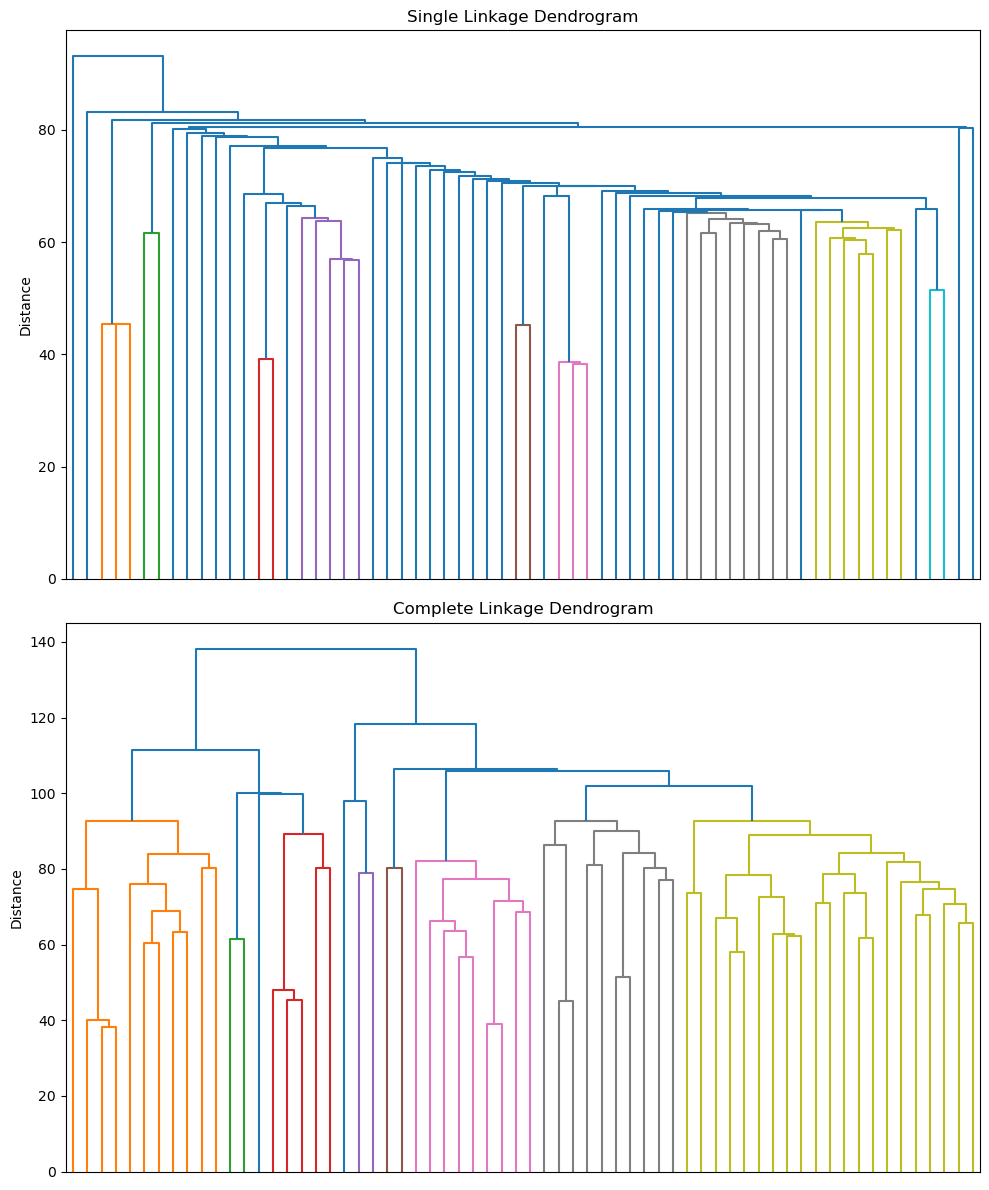

In [12]:
#Problem 3

Z_single   = linkage(nci60_X, method='single')
Z_complete = linkage(nci60_X, method='complete')

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

dendrogram(Z_single, ax=axes[0], no_labels=True)
axes[0].set_title('Single Linkage Dendrogram')
axes[0].set_ylabel('Distance')

dendrogram(Z_complete, ax=axes[1], no_labels=True)
axes[1].set_title('Complete Linkage Dendrogram')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.show()

Single linkage merges clusters based on the minimum distance between any two points across clusters, while complete linkage merges based on the maximum distance. This difference has a significant impact on the shape and balance of the resulting clusters. Single linkage is prone to chaining, where one large cluster gradually absorbs points one at a time, producing elongated and irregular cluster shapes. Complete linkage resists this behavior by ensuring that all points in two clusters are reasonably close before merging, resulting in more compact and roughly equal-sized clusters. Single linkage is also more sensitive to outliers, since a single nearby point can trigger a merge between otherwise distant groups. Complete linkage is more robust in this regard, making it generally better suited for finding well-separated, interpretable clusters in practice.

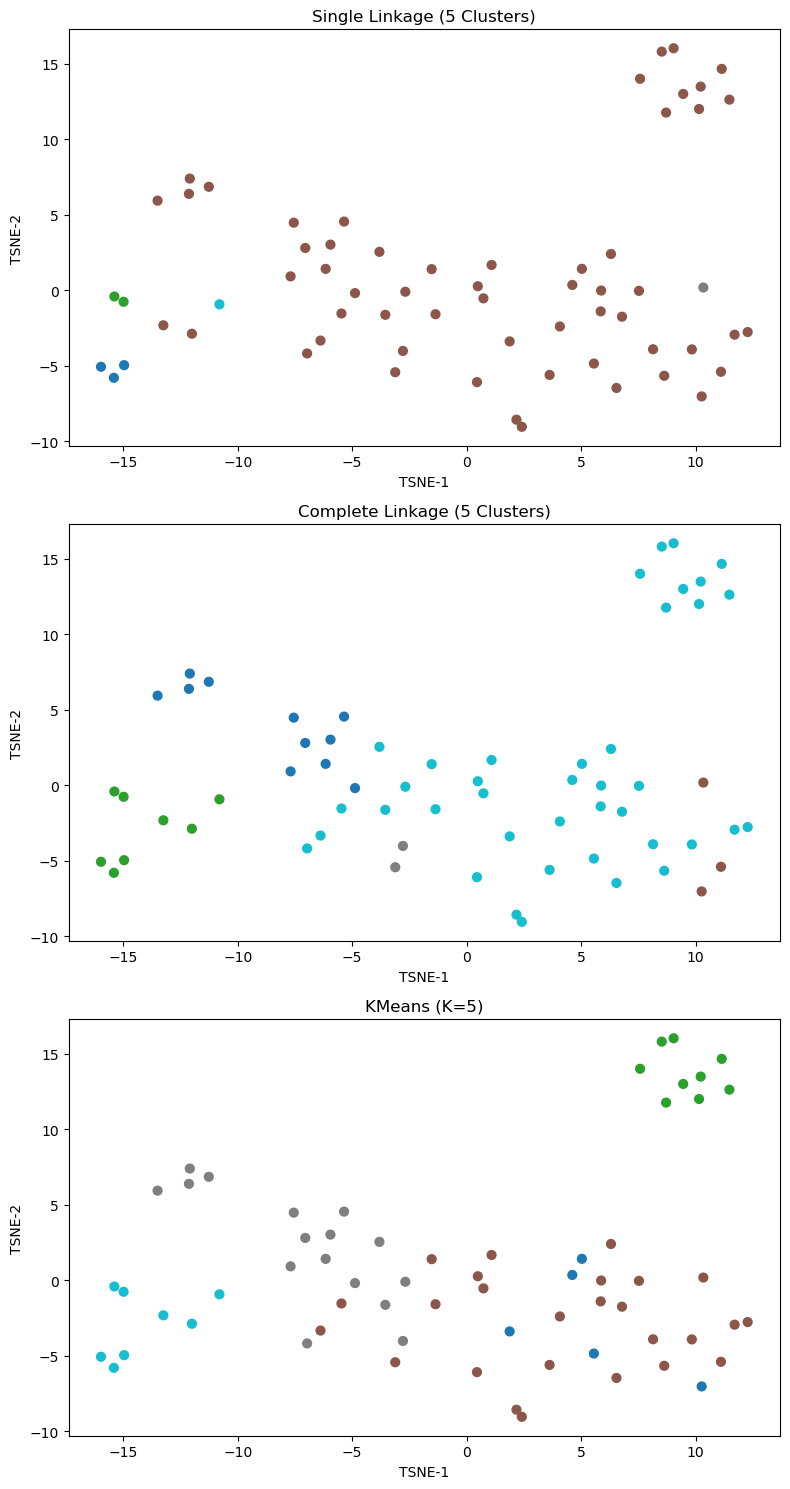

In [13]:
#Problem 4

labels_single   = fcluster(Z_single,   t=5, criterion='maxclust')
labels_complete = fcluster(Z_complete, t=5, criterion='maxclust')

km5 = KMeans(n_clusters=5)
labels_km5 = km5.fit_predict(nci60_X)

fig, axes = plt.subplots(3, 1, figsize=(8, 15))

axes[0].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_single, cmap='tab10', s=40)
axes[0].set_title('Single Linkage (5 Clusters)')
axes[0].set_xlabel('TSNE-1')
axes[0].set_ylabel('TSNE-2')

axes[1].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_complete, cmap='tab10', s=40)
axes[1].set_title('Complete Linkage (5 Clusters)')
axes[1].set_xlabel('TSNE-1')
axes[1].set_ylabel('TSNE-2')

axes[2].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_km5, cmap='tab10', s=40)
axes[2].set_title('KMeans (K=5)')
axes[2].set_xlabel('TSNE-1')
axes[2].set_ylabel('TSNE-2')

plt.tight_layout()
plt.show()

Single linkage tends to produce one very large cluster containing most points, with the remaining clusters being very small or singleton groups. This is a direct consequence of its chaining behavior discussed in Part 3. KMeans, by contrast, forces roughly balanced partitions across all 5 clusters by minimizing within-cluster variance, so its clusters appear more evenly distributed across the TSNE embedding.
Complete linkage agrees more closely with KMeans since both methods favor compact, balanced clusters. However, differences still arise because KMeans assumes spherical clusters of similar size in Euclidean space, while complete linkage minimizes cluster diameter and does not make assumptions about shape. As a result, the two methods can disagree on points that lie on the boundaries between groups.

More broadly, all three methods are operating on the original 6830-dimensional space, while the TSNE plot only reflects local neighborhood structure in 2D. This means that clusters which look separated in the TSNE embedding may not correspond cleanly to what any of the three algorithms find in the full feature space, which further explains why their assignments can differ visually.